# Post #01 - An Introduction to ChemML and Chemical Property Modeling

ChemML is a Python package that has been developed over a decade at the Hachmann Lab in UB, with the aim of simplifying machine learning (ML) model development. In this post, I will introduce ChemML by starting from a blank Python environment, and go through ChemML's core modeling capabilities with a molecule dataset from scratch.

### Step 1: Installing ChemML

Installation of ChemML starts with creating a Python environment, and installing some necessary dependencies via conda.

In [1]:
# !conda install -c conda-forge openbabel nb_conda_kernels python-graphviz -y

We then clone the Git repository for ChemML into a local folder to get the latest version, and pip install from there

In [2]:
# !pip install -e ./chemml-master/. --user --force-reinstall

We also need to install a couple of dependencies separately: 

Mordred descriptors (this will be made part of the ChemML install in the next update)

In [3]:
# !pip install mordred

Pytorch (IMPORTANT: make sure the install command matches your machine as described in https://pytorch.org/get-started/locally/):

In [4]:
# !pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

### Step 2: Loading in data

ChemML comes with curated datasets if you want to [explore modeling quickly](https://hachmannlab.github.io/chemml/ipython_notebooks/ml_model.html), but for this tutorial I want to start with a more realistic scenario, and pull a simple dataset.

For this purpose, I'm using the [Jean-Claude Bradley Open Melting Point dataset](https://figshare.com/articles/dataset/Jean_Claude_Bradley_Open_Melting_Point_Datset/1031637?file=1503990). It downloads as an Excel file, but I've changed the format to CSV.

In [5]:
import pandas as pd

data = pd.read_csv('../data/BradleyMeltingPointDataset.csv')
data

,key,name,smiles,mpC,csid,link,source,donotuse,donotusebecause
0,1,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,64018,http://www.alfa.com/en/GP100W.pgm?DSSTK=B24192,Alfa Aesar,NaN,NaN
1,2,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,403764,http://www.alfa.com/en/GP100W.pgm?DSSTK=A13073,Alfa Aesar,NaN,NaN
2,3,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,80080,http://www.alfa.com/en/GP100W.pgm?DSSTK=L15884,Alfa Aesar,NaN,NaN
3,4,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,63701,http://www.alfa.com/en/GP100W.pgm?DSSTK=B20252,Alfa Aesar,NaN,NaN
4,5,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,69388,http://www.alfa.com/en/GP100W.pgm?DSSTK=L08261,Alfa Aesar,NaN,NaN
...,...,...,...,...,...,...,...,...,...
28640,28641,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5,6840,http://chemspider.com/6840,EPISuite-ChemSpider,NaN,NaN
28641,28642,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5,6840,http://www.amazon.com/gp/product/0849304865/,CRC Handbook of Chemistry and Physics,NaN,NaN
28642,28643,xanthene,c1ccc2c(c1)Cc3ccccc3O2,101.5,6840,http://www.sigmaaldrich.com/united-states.html,Sigma-Aldrich,NaN,NaN
28643,28644,Xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0,6840,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,NaN,NaN


Let's do some basic cleanup here - link and source are not necessary. The last two columns are interesting to look at for outlier detection.

In [6]:
df = data.drop(columns=['link','source','csid','key'])
df[df['donotuse'].notna()]

,name,smiles,mpC,donotuse,donotusebecause
77,1-pentene,CCCC=C,-138.0,x,clearly out of range JCB
2765,2-iodoacetamide,C(C(=O)N)I,-94.0,x,sign inversion JCB
4170,3-pentanol,CCC(CC)O,-8.0,x,out of range and 1- and 2-pentanol much closer...
4955,4-chlorobenzeneseleninic acid,c1cc(ccc1Cl)[Se](=O)O,185.0,x,metal - AL
6408,benzaldehyde,c1ccc(cc1)C=O,-26.0,x,repeating value clearly out of range cc
...,...,...,...,...,...
28313,nitrilotrimethylenetris(phosphonic acid),O=P(O)(O)CN(CP(=O)(O)O)CP(=O)(O)O,-14.0,x,aqueous solution
28390,PCB-3,Clc2ccccc2c1ccccc1,78.0,x,all other sources point to 30-34 - EC
28443,phenyl salicylate,O=C(Oc1ccccc1)c2ccccc2O,130.5,x,clearly out of range JCB
28528,sodium chloride,[Na+].[Cl-],804.0,x,salt and metal


A more detailed investigation might be able to salvage some of this data, but there's only about 400 out of 28000 rows affected so it should be safe to set these rows aside.

In [7]:
donotuse = df[df['donotuse'].notna()]
df = df.drop(index=donotuse.index)
df = df.drop(columns=['donotuse','donotusebecause'])
df

,name,smiles,mpC
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0
...,...,...,...
28640,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28641,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28642,xanthene,c1ccc2c(c1)Cc3ccccc3O2,101.5
28643,Xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


Another common tripping point is invalid SMILES codes - I'll filter them out for now and add them back in later

In [8]:
from rdkit.Chem import MolFromSmiles

invalid_smiles = df[df['smiles'].apply(lambda s: MolFromSmiles(s)==None)]
df = df[df['smiles'].apply(lambda s: MolFromSmiles(s)!=None)]

[11:07:55] Explicit valence for atom # 20 C, 5, is greater than permitted
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 23
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 8
[11:07:56] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 8 9 10 11 12 13 14
[11:07:56] Can't kekulize mol.  Unkeku

That should be a decent starting point. For data processing, I'll create a separate dataframe and drop the names.

In [9]:
df1 = df.drop(columns=['name'])
df1

,smiles,mpC
0,c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,c1ccc(c(c1)N)N2CCCCC2,46.0
2,c1cnc(nc1)N2CCNCC2,33.0
3,c1ccc(c(c1)N2CCNCC2)O,125.0
4,C1CCC(=CC1)CCN,-55.0
...,...,...
28640,c1ccc2c(c1)Cc3ccccc3O2,100.5
28641,c1ccc2c(c1)Cc3ccccc3O2,100.5
28642,c1ccc2c(c1)Cc3ccccc3O2,101.5
28643,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


In [10]:
df1 = df1[df1['smiles'].str.lower().str.contains('c')]
df1

,smiles,mpC
0,c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,c1ccc(c(c1)N)N2CCCCC2,46.0
2,c1cnc(nc1)N2CCNCC2,33.0
3,c1ccc(c(c1)N2CCNCC2)O,125.0
4,C1CCC(=CC1)CCN,-55.0
...,...,...
28640,c1ccc2c(c1)Cc3ccccc3O2,100.5
28641,c1ccc2c(c1)Cc3ccccc3O2,100.5
28642,c1ccc2c(c1)Cc3ccccc3O2,101.5
28643,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


In [11]:
from rdkit import Chem
from collections import defaultdict

def atomcounter(m):
    atomic_count = defaultdict(lambda : 0)
    for atom in m.GetAtoms():
        atomic_count[atom.GetAtomicNum()] += 1
    return list(atomic_count)

df2 = df1[df1['smiles'].apply(lambda s: 5 not in atomcounter(MolFromSmiles(s)))]
df2 = df2.reset_index(drop=True)
df2 = df2.dropna(subset='mpC')
df2

,smiles,mpC
0,c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,c1ccc(c(c1)N)N2CCCCC2,46.0
2,c1cnc(nc1)N2CCNCC2,33.0
3,c1ccc(c(c1)N2CCNCC2)O,125.0
4,C1CCC(=CC1)CCN,-55.0
...,...,...
27679,c1ccc2c(c1)Cc3ccccc3O2,100.5
27680,c1ccc2c(c1)Cc3ccccc3O2,100.5
27681,c1ccc2c(c1)Cc3ccccc3O2,101.5
27682,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


Selecting a small subset in the interest of time:

In [12]:
df2 = df2.sample(2000, random_state=42)

### Step 3: Data representation and preprocessing using ChemML

ChemML has modules for both representing molecules, as well as cleaning up the resulting feature data. We have several features available to us, but for now we can use the Mordred descriptor library that is integrated into ChemML.

In [13]:
from chemml.chem import Mordred, Molecule

smis = df2['smiles'].tolist()
mols = [Molecule(s, input_type='smiles') for s in smis] 

len(mols)

2000

In [14]:
# Instantiate a Mordred object to generate descriptors
mord = Mordred()

# Generate descriptor DataFrame
descs = mord.represent(mols)

c:\Users\nitin\miniconda3\envs\nitin_py312_env\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\nitin\miniconda3\envs\nitin_py312_env\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\nitin\miniconda3\envs\nitin_py312_env\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\nitin\miniconda3\envs\nitin_py312_env\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [15]:
descs

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,SM1_A,VE1_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,SMILES
0,0,0,10.424292,2.135779,4.271558,10.424292,1.303037,2.969338,2.220446e-15,2.718002,...,35.247635,108.057515,6.753595,64,7,34.0,36.0,2.611111,2.000000,COc1ccccc1
1,0,0,18.187239,2.445348,4.696550,18.187239,1.212483,3.601552,1.399070e-15,3.357454,...,61.082038,212.079707,7.854804,353,23,72.0,85.0,7.416667,3.555556,COC(=O)c1c(C)nn(C(=O)OC)c1C
2,0,0,13.132593,2.305040,4.610080,13.132593,1.193872,3.294669,-3.275158e-15,3.089123,...,41.025392,172.003955,10.750247,148,14,52.0,58.0,5.194444,2.472222,Nc1ccc(Cl)cc1[N+](=O)[O-]
3,0,0,15.474933,2.358051,4.716102,15.474933,1.289578,3.426258,0.000000e+00,3.285243,...,43.064730,159.068414,7.574686,186,16,62.0,71.0,3.944444,2.611111,Nc1ccc2cc(O)ccc2c1
4,0,0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,7.993606e-15,2.673468,...,32.187603,132.097272,5.504053,84,5,26.0,24.0,3.500000,2.250000,CCCCCCCS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,9.924777,2.170086,4.340173,9.924777,1.240597,2.979730,1.332268e-15,2.742040,...,35.730685,189.918490,15.826541,62,7,36.0,38.0,3.222222,1.833333,Clc1ccc(Br)cc1
1996,0,0,14.591850,2.256021,4.512042,14.591850,1.215988,3.368469,-6.661338e-16,3.170346,...,41.876660,164.083730,6.836822,211,14,54.0,59.0,4.833333,2.861111,CCCC(=O)c1ccc(O)cc1
1997,0,0,10.128990,2.236068,4.472136,10.128990,1.125443,3.099014,2.220446e-16,2.867913,...,37.736937,247.883624,16.525575,84,9,42.0,45.0,4.083333,2.000000,Cc1cc(Br)cc(Br)c1
1998,0,0,9.924777,2.170086,4.340173,9.924777,1.240597,2.979730,1.332268e-15,2.742040,...,35.730685,219.938513,16.918347,62,7,36.0,38.0,3.222222,1.833333,Oc1ccc(I)cc1


We can use ChemML to remove constant columns - columns where there is only value, which do not contain any valuable information and can unnecessarily increase model complexity

In [16]:
from chemml.preprocessing import ConstantColumns, Outliers

descs = ConstantColumns(descs)
descs

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,SM1_A,VE1_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,SMILES
0,0,0,10.424292,2.135779,4.271558,10.424292,1.303037,2.969338,2.220446e-15,2.718002,...,35.247635,108.057515,6.753595,64,7,34.0,36.0,2.611111,2.000000,COc1ccccc1
1,0,0,18.187239,2.445348,4.696550,18.187239,1.212483,3.601552,1.399070e-15,3.357454,...,61.082038,212.079707,7.854804,353,23,72.0,85.0,7.416667,3.555556,COC(=O)c1c(C)nn(C(=O)OC)c1C
2,0,0,13.132593,2.305040,4.610080,13.132593,1.193872,3.294669,-3.275158e-15,3.089123,...,41.025392,172.003955,10.750247,148,14,52.0,58.0,5.194444,2.472222,Nc1ccc(Cl)cc1[N+](=O)[O-]
3,0,0,15.474933,2.358051,4.716102,15.474933,1.289578,3.426258,0.000000e+00,3.285243,...,43.064730,159.068414,7.574686,186,16,62.0,71.0,3.944444,2.611111,Nc1ccc2cc(O)ccc2c1
4,0,0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,7.993606e-15,2.673468,...,32.187603,132.097272,5.504053,84,5,26.0,24.0,3.500000,2.250000,CCCCCCCS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,9.924777,2.170086,4.340173,9.924777,1.240597,2.979730,1.332268e-15,2.742040,...,35.730685,189.918490,15.826541,62,7,36.0,38.0,3.222222,1.833333,Clc1ccc(Br)cc1
1996,0,0,14.591850,2.256021,4.512042,14.591850,1.215988,3.368469,-6.661338e-16,3.170346,...,41.876660,164.083730,6.836822,211,14,54.0,59.0,4.833333,2.861111,CCCC(=O)c1ccc(O)cc1
1997,0,0,10.128990,2.236068,4.472136,10.128990,1.125443,3.099014,2.220446e-16,2.867913,...,37.736937,247.883624,16.525575,84,9,42.0,45.0,4.083333,2.000000,Cc1cc(Br)cc(Br)c1
1998,0,0,9.924777,2.170086,4.340173,9.924777,1.240597,2.979730,1.332268e-15,2.742040,...,35.730685,219.938513,16.918347,62,7,36.0,38.0,3.222222,1.833333,Oc1ccc(I)cc1


In [17]:
targets = df2['mpC'].to_frame()
descs = descs.drop(columns='SMILES')

In [18]:
targets.min()

mpC   -205.0
dtype: float64

### Step 4. Building a DNN model using ChemML

ChemML implements a simplified neural network calling object, which uses either TensorFlow or Pytorch as the backend.
For this study, I'll test out Pytorch.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(descs.values, targets.values, random_state=42)

xscale = StandardScaler()
yscale = StandardScaler()

X_train = xscale.fit_transform(X_train)
X_test = xscale.transform(X_test)

y_train = yscale.fit_transform(y_train)

In [20]:
from chemml.models import MLP


mlp = MLP(engine='pytorch',nfeatures=X_train.shape[1], nneurons=[32,64,64], activations=['ReLU','ReLU','ReLU'],
                learning_rate=3e-4, alpha=0.002, nepochs=300, batch_size=int(len(X_train)/10), loss='mean_squared_error',
                is_regression=True, nclasses=None, layer_config_file=None, opt_config='sgd')

mlp.fit(X = X_train, y = y_train)

In [21]:
import numpy as np

y_pred = mlp.predict(X_test)
y_pred = yscale.inverse_transform(y_pred.reshape(-1,1))

In [22]:
from chemml.utils import regression_metrics

# For the regression_metrics function the inputs must have the same data type
metrics_df = regression_metrics(y_test, y_pred)
print("Metrics: \n")
print(metrics_df)

Metrics: 

         ME        MAE          MSE       RMSE       MAPE       MaxAPE  \
0 -2.217157  34.193928  2241.869711  47.348387  71.815019  2704.732513   

        RMSPE       MPE       MaxAE   deltaMaxE  r_squared        std  
0  216.852248  5.994246  265.080685  433.572011   0.757964  96.242163  


The Plot has been saved at:  .\images/Parity.png


C:\Users\nitin\AppData\Local\Temp\ipykernel_12640\4238640246.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


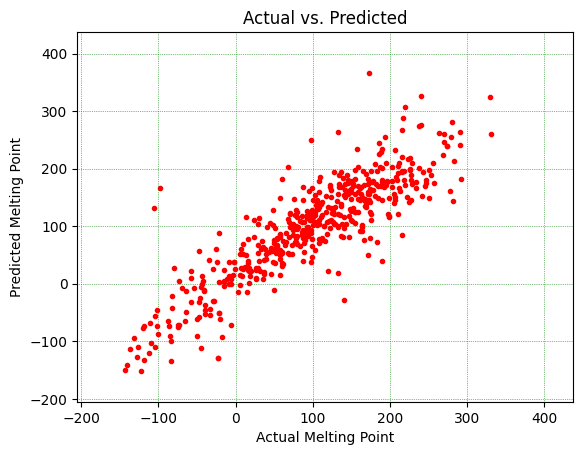

In [23]:
from chemml.visualization import scatter2D, SavePlot, decorator
import pandas as pd
%matplotlib inline
df = pd.DataFrame()
df["Actual"] = y_test.reshape(-1,)
df["Predicted"] = y_pred.reshape(-1,)
sc = scatter2D('r', marker='.')
fig = sc.plot(dfx=df, dfy=df, x="Actual", y="Predicted")

dec = decorator(title='Actual vs. Predicted',xlabel='Actual Melting Point', ylabel='Predicted Melting Point',
                xlim= (targets.min().values,targets.max().values), ylim=(targets.min().values,targets.max().values), 
                grid=True, grid_color='g', grid_linestyle=':', grid_linewidth=0.5)
fig = dec.fit(fig)
# print(type(fig))
sa=SavePlot(filename='Parity',output_directory='images',
            kwargs={'facecolor':'w','dpi':330,'pad_inches':0.1, 'bbox_inches':'tight'})
sa.save(obj=fig)
fig.show()

### Step 5: Data refinements and AutoML

So how do we get this model to do better?

There's two directions to go from here:

1. Improve data quality via feature selection and engineering
2. Improve model performance via hyperparameter optimization

We have some basic feature reduction that can be done (this will be incorporated into ChemML in a release coming soon)

In [24]:
# Remove highly correlated features
feat_corr_matrix = descs.corr().abs()
upper_tri = feat_corr_matrix.where(np.triu(np.ones(feat_corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
len(to_drop)

560

In [25]:
features = descs.drop(columns=to_drop)
features

,nAcid,nBase,SpAbs_A,SpMax_A,SpMAD_A,SM1_A,VR1_A,nAromAtom,nAtom,nSpiro,...,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,JGT10,TopoShapeIndex,TopoPSA(NO),SRW05
0,0,0,10.424292,2.135779,1.303037,2.220446e-15,23.560979,6,16,0,...,0.062500,0.000000,0.000000,0.0,0.0,0.0,0.314039,0.666667,9.23,0.000000
1,0,0,18.187239,2.445348,1.212483,1.399070e-15,73.382896,5,27,0,...,0.033675,0.017493,0.007812,0.0,0.0,0.0,0.547960,1.000000,70.42,2.397895
2,0,0,13.132593,2.305040,1.193872,-3.275158e-15,37.182651,6,16,0,...,0.025000,0.000000,0.000000,0.0,0.0,0.0,0.533729,0.666667,69.16,0.000000
3,0,0,15.474933,2.358051,1.289578,0.000000e+00,47.192679,10,21,0,...,0.018519,0.060408,0.000000,0.0,0.0,0.0,0.505499,0.750000,46.25,0.000000
4,0,0,9.517541,1.879385,1.189693,7.993606e-15,21.482988,0,24,0,...,0.018519,0.020408,0.000000,0.0,0.0,0.0,0.192392,0.750000,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,9.924777,2.170086,1.240597,1.332268e-15,22.227825,6,12,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.525714,0.666667,0.00,0.000000
1996,0,0,14.591850,2.256021,1.215988,-6.661338e-16,50.071639,6,24,0,...,0.037698,0.020245,0.029514,0.0,0.0,0.0,0.482359,1.000000,37.30,0.000000
1997,0,0,10.128990,2.236068,1.125443,2.220446e-16,26.528645,6,15,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.548611,0.333333,0.00,0.000000
1998,0,0,9.924777,2.170086,1.240597,1.332268e-15,22.227825,6,13,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.525714,0.666667,20.23,0.000000


In [26]:
# Remove invariant features
features_binary = features.loc[:, features.nunique() == 2]
invariant_cols = [col for col in features_binary.columns if features_binary[col].value_counts().max() > 0.9 * len(features_binary)]
single_value_cols = features.loc[:, features.nunique() == 1].columns.tolist()
len(invariant_cols), len(single_value_cols)

(29, 0)

In [27]:
features = features.drop(columns=invariant_cols + single_value_cols)
features

,nAcid,nBase,SpAbs_A,SpMax_A,SpMAD_A,SM1_A,VR1_A,nAromAtom,nAtom,nSpiro,...,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,JGT10,TopoShapeIndex,TopoPSA(NO),SRW05
0,0,0,10.424292,2.135779,1.303037,2.220446e-15,23.560979,6,16,0,...,0.062500,0.000000,0.000000,0.0,0.0,0.0,0.314039,0.666667,9.23,0.000000
1,0,0,18.187239,2.445348,1.212483,1.399070e-15,73.382896,5,27,0,...,0.033675,0.017493,0.007812,0.0,0.0,0.0,0.547960,1.000000,70.42,2.397895
2,0,0,13.132593,2.305040,1.193872,-3.275158e-15,37.182651,6,16,0,...,0.025000,0.000000,0.000000,0.0,0.0,0.0,0.533729,0.666667,69.16,0.000000
3,0,0,15.474933,2.358051,1.289578,0.000000e+00,47.192679,10,21,0,...,0.018519,0.060408,0.000000,0.0,0.0,0.0,0.505499,0.750000,46.25,0.000000
4,0,0,9.517541,1.879385,1.189693,7.993606e-15,21.482988,0,24,0,...,0.018519,0.020408,0.000000,0.0,0.0,0.0,0.192392,0.750000,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,9.924777,2.170086,1.240597,1.332268e-15,22.227825,6,12,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.525714,0.666667,0.00,0.000000
1996,0,0,14.591850,2.256021,1.215988,-6.661338e-16,50.071639,6,24,0,...,0.037698,0.020245,0.029514,0.0,0.0,0.0,0.482359,1.000000,37.30,0.000000
1997,0,0,10.128990,2.236068,1.125443,2.220446e-16,26.528645,6,15,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.548611,0.333333,0.00,0.000000
1998,0,0,9.924777,2.170086,1.240597,1.332268e-15,22.227825,6,13,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.525714,0.666667,20.23,0.000000


In [28]:
invariant_nonbinary_cols = [col for col in features.columns if features[col].nunique() > 2 and features[col].value_counts().max() > 0.9 * len(features)]
len(invariant_nonbinary_cols)

45

In [29]:
features = features.drop(columns=invariant_nonbinary_cols)
features

,nAcid,SpAbs_A,SpMax_A,SpMAD_A,SM1_A,VR1_A,nAromAtom,nAtom,nN,nO,...,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,JGT10,TopoShapeIndex,TopoPSA(NO),SRW05
0,0,10.424292,2.135779,1.303037,2.220446e-15,23.560979,6,16,0,1,...,0.062500,0.000000,0.000000,0.0,0.0,0.0,0.314039,0.666667,9.23,0.000000
1,0,18.187239,2.445348,1.212483,1.399070e-15,73.382896,5,27,2,4,...,0.033675,0.017493,0.007812,0.0,0.0,0.0,0.547960,1.000000,70.42,2.397895
2,0,13.132593,2.305040,1.193872,-3.275158e-15,37.182651,6,16,2,2,...,0.025000,0.000000,0.000000,0.0,0.0,0.0,0.533729,0.666667,69.16,0.000000
3,0,15.474933,2.358051,1.289578,0.000000e+00,47.192679,10,21,1,1,...,0.018519,0.060408,0.000000,0.0,0.0,0.0,0.505499,0.750000,46.25,0.000000
4,0,9.517541,1.879385,1.189693,7.993606e-15,21.482988,0,24,0,0,...,0.018519,0.020408,0.000000,0.0,0.0,0.0,0.192392,0.750000,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,9.924777,2.170086,1.240597,1.332268e-15,22.227825,6,12,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.525714,0.666667,0.00,0.000000
1996,0,14.591850,2.256021,1.215988,-6.661338e-16,50.071639,6,24,0,2,...,0.037698,0.020245,0.029514,0.0,0.0,0.0,0.482359,1.000000,37.30,0.000000
1997,0,10.128990,2.236068,1.125443,2.220446e-16,26.528645,6,15,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.548611,0.333333,0.00,0.000000
1998,0,9.924777,2.170086,1.240597,1.332268e-15,22.227825,6,13,0,1,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.525714,0.666667,20.23,0.000000


In [30]:
# Get variance of features and filter out features with very low variance and low correlation
feature_variances = features.var()
low_variance_cols = feature_variances[feature_variances < 0.01].index
len(low_variance_cols)

28

In [31]:
features = features.drop(columns=low_variance_cols)
features

,nAcid,SpAbs_A,SpMax_A,VR1_A,nAromAtom,nAtom,nN,nO,nS,nCl,...,nFHRing,nFARing,nRot,RotRatio,SLogP,JGI1,JGT10,TopoShapeIndex,TopoPSA(NO),SRW05
0,0,10.424292,2.135779,23.560979,6,16,0,1,0,0,...,0,0,1,0.125000,1.69520,0.125000,0.314039,0.666667,9.23,0.000000
1,0,18.187239,2.445348,73.382896,5,27,2,4,0,0,...,0,0,1,0.066667,0.90104,0.233333,0.547960,1.000000,70.42,2.397895
2,0,13.132593,2.305040,37.182651,6,16,2,2,0,1,...,0,0,1,0.090909,1.83040,0.272727,0.533729,0.666667,69.16,0.000000
3,0,15.474933,2.358051,47.192679,10,21,1,1,0,0,...,0,0,0,0.000000,2.12760,0.230769,0.505499,0.750000,46.25,0.000000
4,0,9.517541,1.879385,21.482988,0,24,0,0,1,0,...,0,0,5,0.714286,2.88660,0.071429,0.192392,0.750000,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,9.924777,2.170086,22.227825,6,12,0,0,0,1,...,0,0,0,0.000000,3.10250,0.250000,0.525714,0.666667,0.00,0.000000
1996,0,14.591850,2.256021,50.071639,6,24,0,2,0,0,...,0,0,3,0.250000,2.37500,0.208333,0.482359,1.000000,37.30,0.000000
1997,0,10.128990,2.236068,26.528645,6,15,0,0,0,0,...,0,0,0,0.000000,3.52002,0.333333,0.548611,0.333333,0.00,0.000000
1998,0,9.924777,2.170086,22.227825,6,13,0,1,0,0,...,0,0,0,0.000000,1.99680,0.250000,0.525714,0.666667,20.23,0.000000


In [32]:
X_train, X_test, y_train, y_test = train_test_split(features.values, targets.values, random_state=42)

xscale = StandardScaler()
yscale = StandardScaler()

X_train = xscale.fit_transform(X_train)
X_test = xscale.transform(X_test)

y_train_act = y_train
y_train = yscale.fit_transform(y_train)

In [33]:
from chemml.models import MLP


mlp = MLP(engine='pytorch',nfeatures=X_train.shape[1], nneurons=[32,64,64], activations=['ReLU','ReLU','ReLU'],
                learning_rate=3e-4, alpha=0.002, nepochs=300, batch_size=int(len(X_train)/10), loss='mean_squared_error',
                is_regression=True, nclasses=None, layer_config_file=None, opt_config='sgd')

mlp.fit(X = X_train, y = y_train)

In [34]:
import numpy as np

y_pred = mlp.predict(X_test)
y_pred = yscale.inverse_transform(y_pred.reshape(-1,1))

In [35]:
from chemml.utils import regression_metrics

# For the regression_metrics function the inputs must have the same data type
metrics_df_reduced = regression_metrics(y_test, y_pred)
metrics_df_combi = pd.concat([metrics_df, metrics_df_reduced])
metrics_df_combi['data'] = ['full','reduced']
print("Metrics: \n")
metrics_df_combi[['data','MAE','RMSE','r_squared']]

Metrics: 



,data,MAE,RMSE,r_squared
0,full,34.193928,47.348387,0.757964
0,reduced,37.199673,60.000681,0.611329


The Plot has been saved at:  .\images/Parity_ohe.png


C:\Users\nitin\AppData\Local\Temp\ipykernel_12640\2819632029.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


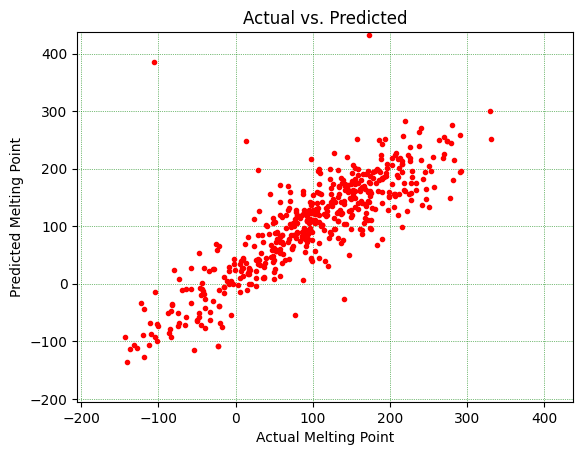

In [36]:
from chemml.visualization import scatter2D, SavePlot, decorator
import pandas as pd
%matplotlib inline
df = pd.DataFrame()
df["Actual"] = y_test.reshape(-1,)
df["Predicted"] = y_pred.reshape(-1,)
sc = scatter2D('r', marker='.')
fig = sc.plot(dfx=df, dfy=df, x="Actual", y="Predicted")

dec = decorator(title='Actual vs. Predicted',xlabel='Actual Melting Point', ylabel='Predicted Melting Point',
                xlim= (targets.min().values,targets.max().values), ylim=(targets.min().values,targets.max().values), 
                grid=True, grid_color='g', grid_linestyle=':', grid_linewidth=0.5)
fig = dec.fit(fig)
# print(type(fig))
sa=SavePlot(filename='Parity_ohe',output_directory='images',
            kwargs={'facecolor':'w','dpi':330,'pad_inches':0.1, 'bbox_inches':'tight'})
sa.save(obj=fig)
fig.show()

We don't lose much performance when compared to the full 897-feature set, which shows that the vast majority of these features was noise. But how do we do better?

In [37]:
from sklearn.preprocessing import MinMaxScaler

df3 = features.copy()
y = targets.reset_index(drop=True)['mpC'].values
yscale = MinMaxScaler().fit(y_train_act)
y = yscale.transform(y.reshape(-1,1))
df3['mpC'] = y
df3

,nAcid,SpAbs_A,SpMax_A,VR1_A,nAromAtom,nAtom,nN,nO,nS,nCl,...,nFARing,nRot,RotRatio,SLogP,JGI1,JGT10,TopoShapeIndex,TopoPSA(NO),SRW05,mpC
0,0,10.424292,2.135779,23.560979,6,16,0,1,0,0,...,0,1,0.125000,1.69520,0.125000,0.314039,0.666667,9.23,0.000000,0.261560
1,0,18.187239,2.445348,73.382896,5,27,2,4,0,0,...,0,1,0.066667,0.90104,0.233333,0.547960,1.000000,70.42,2.397895,0.459287
2,0,13.132593,2.305040,37.182651,6,16,2,2,0,1,...,0,1,0.090909,1.83040,0.272727,0.533729,0.666667,69.16,0.000000,0.500545
3,0,15.474933,2.358051,47.192679,10,21,1,1,0,0,...,0,0,0.000000,2.12760,0.230769,0.505499,0.750000,46.25,0.000000,0.607193
4,0,9.517541,1.879385,21.482988,0,24,0,0,1,0,...,0,5,0.714286,2.88660,0.071429,0.192392,0.750000,0.00,0.000000,0.252219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,9.924777,2.170086,22.227825,6,12,0,0,0,1,...,0,0,0.000000,3.10250,0.250000,0.525714,0.666667,0.00,0.000000,0.420364
1996,0,14.591850,2.256021,50.071639,6,24,0,2,0,0,...,0,3,0.250000,2.37500,0.208333,0.482359,1.000000,37.30,0.000000,0.460844
1997,0,10.128990,2.236068,26.528645,6,15,0,0,0,0,...,0,0,0.000000,3.52002,0.333333,0.548611,0.333333,0.00,0.000000,0.379885
1998,0,9.924777,2.170086,22.227825,6,13,0,1,0,0,...,0,0,0.000000,1.99680,0.250000,0.525714,0.666667,20.23,0.000000,0.463958


In [38]:
from chemml.autoML import ModelScreener

MS = ModelScreener(df3, target="mpC", featurization=False,  
                   screener_type="regressor", output_file="mpc_demo.txt")
scores = MS.screen_models(n_best=4, multi_core=False)

split done!
Single-core complete 


------------------------- Screening complete for feature set user_given, time taken: 25.237 seconds -------------------------



In [39]:
scores[['Model','parameters','MAE','RMSE','r_squared']]

,Model,parameters,MAE,RMSE,r_squared
3,DecisionTreeRegressor,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",0.073588,0.093897,0.598766
2,ElasticNet,"{'alpha': 0.0006158482110660269, 'copy_X': Tru...",0.063483,0.093971,0.598135
1,Lasso,"{'alpha': 0.0002976351441631321, 'copy_X': Tru...",0.063384,0.094046,0.597492
0,Ridge,"{'alpha': 191.20000000000002, 'copy_X': True, ...",0.064819,0.094700,0.591877


### Step 6. Feature selection via Genetic Algorithms

While we have primarily utilized the genetic algorithm via the AutoML backend to select optimal model hyperparameters, we can use it to also reduce the number of features and select only the useful data, beyond what standard data cleaning can acheive.

In [40]:
from sklearn.linear_model import LinearRegression
from chemml.optimization import GeneticAlgorithm
from sklearn.metrics import mean_absolute_error

space = tuple([{i: {'choice': [0,1]}} for i in range(features.shape[1])])

def obj(individual, features=features):
    df = pd.DataFrame(features, columns=features.columns)
    new_cols = list(map(bool, individual))
    df = df[df.columns[new_cols]]
    features = df.values

    X_train_ga, X_test_ga, y_train_ga, y_test_ga = train_test_split(features, y, test_size=0.7, random_state=42)
    xscale_ga= StandardScaler()
    yscale_ga = StandardScaler()

    X_train_ga = xscale_ga.fit_transform(X_train_ga)
    X_test_ga = xscale_ga.transform(X_test_ga)
    y_train_ga = yscale_ga.fit_transform(y_train_ga.reshape(-1, 1)).flatten()

    reg = LinearRegression().fit(X_train_ga, y_train_ga)
    pred = yscale_ga.inverse_transform(reg.predict(X_test_ga).reshape(-1, 1)).flatten()
    return mean_absolute_error(y_test_ga, pred)

ga = GeneticAlgorithm(evaluate=obj, space=space, fitness=("min", ), crossover_type="Uniform",
                        pop_size = 100, crossover_size=60, mutation_size=40, algorithm=3)
fitness_df, final_best_features = ga.search(n_generations=50)
# fitness_df.drop_duplicates(subset='Best_individual').tail(10)

col_mask = [True if v==1 else False for _, v in final_best_features.items()]
features_ga = features.loc[:, col_mask]
features_ga.shape

Generation:   0%|          | 0/50 [00:00<?, ?gen/s]

The search converged with convergence criteria =  10


(2000, 117)

In [42]:
df4 = features_ga.copy()
df4['mpC'] = y
df4

,nAromAtom,nO,nX,ATS0dv,ATS0s,AATS0dv,AATS0d,AATS1i,ATSC6dv,ATSC7dv,...,AMID_O,AMID_X,n6HRing,nFHRing,nFARing,SLogP,JGI1,TopoShapeIndex,SRW05,mpC
0,6,1,0,98.000000,47.027778,6.125000,2.625000,143.277073,10.156250,7.921875,...,0.235074,0.000000,0,0,0,1.69520,0.125000,0.666667,0.000000,0.261560
1,5,4,0,278.000000,177.388889,10.296296,3.111111,151.619162,32.067215,97.832647,...,0.478747,0.000000,0,0,0,0.90104,0.233333,1.000000,2.397895,0.459287
2,6,2,1,185.604938,158.921963,11.600309,3.562500,155.287769,-10.734568,0.000000,...,0.309749,0.159644,0,0,0,1.83040,0.272727,0.666667,0.000000,0.500545
3,10,1,0,152.000000,96.111111,7.238095,3.380952,145.951882,-4.000000,19.000000,...,0.147403,0.000000,0,0,0,2.12760,0.230769,0.750000,0.000000,0.607193
4,0,0,0,25.308642,35.054793,1.054527,1.750000,144.136573,-1.250514,0.100566,...,0.000000,0.000000,0,0,0,2.88660,0.071429,0.750000,0.000000,0.252219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,6,0,2,68.672154,28.500238,5.722679,3.333333,137.691889,0.000000,0.000000,...,0.000000,0.436895,0,0,0,3.10250,0.250000,0.666667,0.000000,0.420364
1996,6,2,0,154.000000,129.833333,6.416667,2.750000,143.506772,4.000000,-10.444444,...,0.292796,0.000000,0,0,0,2.37500,0.208333,1.000000,0.000000,0.460844
1997,6,0,2,76.134431,32.600995,5.075629,3.200000,138.156643,6.761116,0.000000,...,0.000000,0.388286,0,0,0,3.52002,0.333333,0.333333,0.000000,0.379885
1998,6,1,1,93.024198,63.605953,7.155708,3.153846,140.728327,3.443384,0.000000,...,0.218448,0.218448,0,0,0,1.99680,0.250000,0.666667,0.000000,0.463958


In [47]:
MS = ModelScreener(df4, target="mpC", featurization=False,  
                   screener_type="regressor", output_file="mpc_demo_ga.txt")
scores_ga = MS.screen_models(n_best=4, multi_core=False)

split done!
Single-core complete 


------------------------- Screening complete for feature set user_given, time taken: 16.47 seconds -------------------------



In [48]:
scores_ga[['Model','parameters','MAE','RMSE','r_squared']]

,Model,parameters,MAE,RMSE,r_squared
3,ElasticNet,"{'alpha': 0.00010000000000000009, 'copy_X': Tr...",0.059884,0.080846,0.702553
1,Lasso,"{'alpha': 0.00020691380811147916, 'copy_X': Tr...",0.060328,0.081740,0.695938
0,Ridge,"{'alpha': 5.0, 'copy_X': True, 'fit_intercept'...",0.061510,0.083244,0.684642
2,DecisionTreeRegressor,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",0.068122,0.089937,0.631895


In [ ]:
scores_ga.iloc[0].parameters

{'alpha': 0.00010000000000000009,
 'copy_X': True,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

In [50]:
from sklearn.linear_model import ElasticNet

X_train_ga, X_test_ga, y_train, y_test = train_test_split(features_ga.values, y, test_size=0.7, random_state=42)

xscale_ga= StandardScaler()
yscale_ga = StandardScaler()

X_train_ga = xscale_ga.fit_transform(X_train_ga)
X_test_ga = xscale_ga.transform(X_test_ga)

y_train = yscale_ga.fit_transform(y_train.reshape(-1, 1)).flatten()

model_ga = ElasticNet(alpha=0.0001, l1_ratio=0.5, max_iter=1000, random_state=42)
model_ga.fit(X_train_ga, y_train)
# model_ga.score(X_test_ga, y_test)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.0001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [51]:
y_pred_ga = model_ga.predict(X_test_ga)
y_pred_ga = yscale_ga.inverse_transform(y_pred_ga.reshape(-1,1))

metrics_df_ga = regression_metrics(y_test, y_pred_ga)
metrics_df_ga

,ME,MAE,MSE,RMSE,MaxAE,deltaMaxE,r_squared,std
0,-0.006938,0.059413,0.00665,0.081545,0.562325,0.974854,0.704556,0.150024


In [52]:
metrics_df_combi = pd.concat([metrics_df, metrics_df_reduced, metrics_df_ga])
metrics_df_combi['data'] = ['full','reduced','ga']
metrics_df_combi[['data','MAE','RMSE','r_squared']]

,data,MAE,RMSE,r_squared
0,full,34.193928,47.348387,0.757964
0,reduced,37.199673,60.000681,0.611329
0,ga,0.059413,0.081545,0.704556
